# **Cardiac Diagnosis Case Study**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.stats import boxcox
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
#Customising for the plotted figures
plt.rcParams['figure.dpi'] = 200
sns.set(rc={'axes.facecolor': '#faded9'}, style='darkgrid')

## **-->** Importing Dataset




In [3]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart.csv


In [4]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


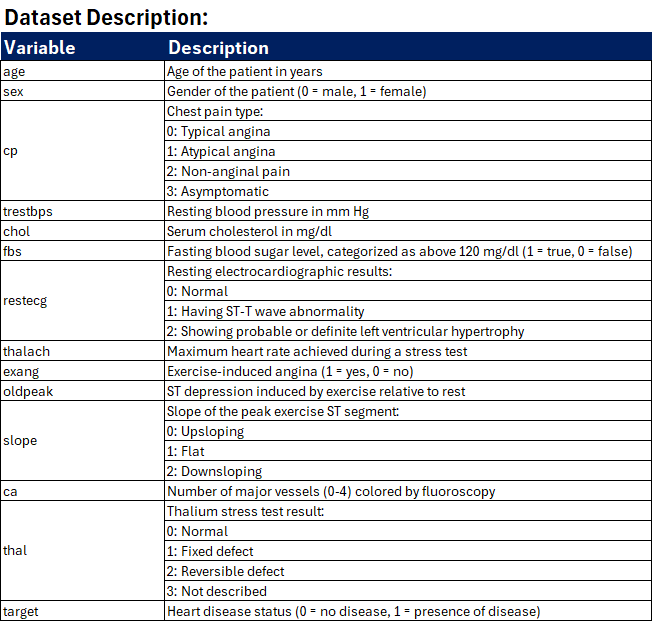

In [5]:
# Summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


The data contains 303 entries with no missing values.

All the variables except ``thal`` Thalium stess test result are of int64 datatype. The thal is of float64 type

> Manually observing the dataset we can conclude columns like ``sex``, ``cp``, ``fbs`` are of categorical type not integer in mathematial term. This features should be converted to string(object) datatype for proper analisis.







In [6]:
# First we define the continuous features an the convert the rest into object
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
ftc = [feature for feature in df.columns if feature not in continuous_features]
df[ftc] = df[ftc].astype('object')

df.dtypes

,0
age,int64
sex,object
cp,object
trestbps,int64
chol,int64
fbs,object
restecg,object
thalach,int64
exang,object
oldpeak,float64


Required features are converted to object

In [7]:
# Now let us check the statistical summary of the numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


The above output shows the mean along with the standard deviation of the continuous data of our data sets. It also shows the maximum and minimum observations with the 1st & 2nd Quartile along with the median observation.

In [8]:
# Now we check the summary of the categorical variables
df.describe(include='object')

,sex,cp,fbs,restecg,exang,slope,ca,thal,target
count,303,303,303,303,303,303,303,303,303
unique,2,4,2,3,2,3,5,4,2
top,1,0,0,1,0,2,0,2,1
freq,207,143,258,152,204,142,175,166,165


The result shows the no. of unique values(unique) for each feature stating the the most occured category(top) of each feature with the no. of occurance (freq)



> **Exploratory Data Analysis**



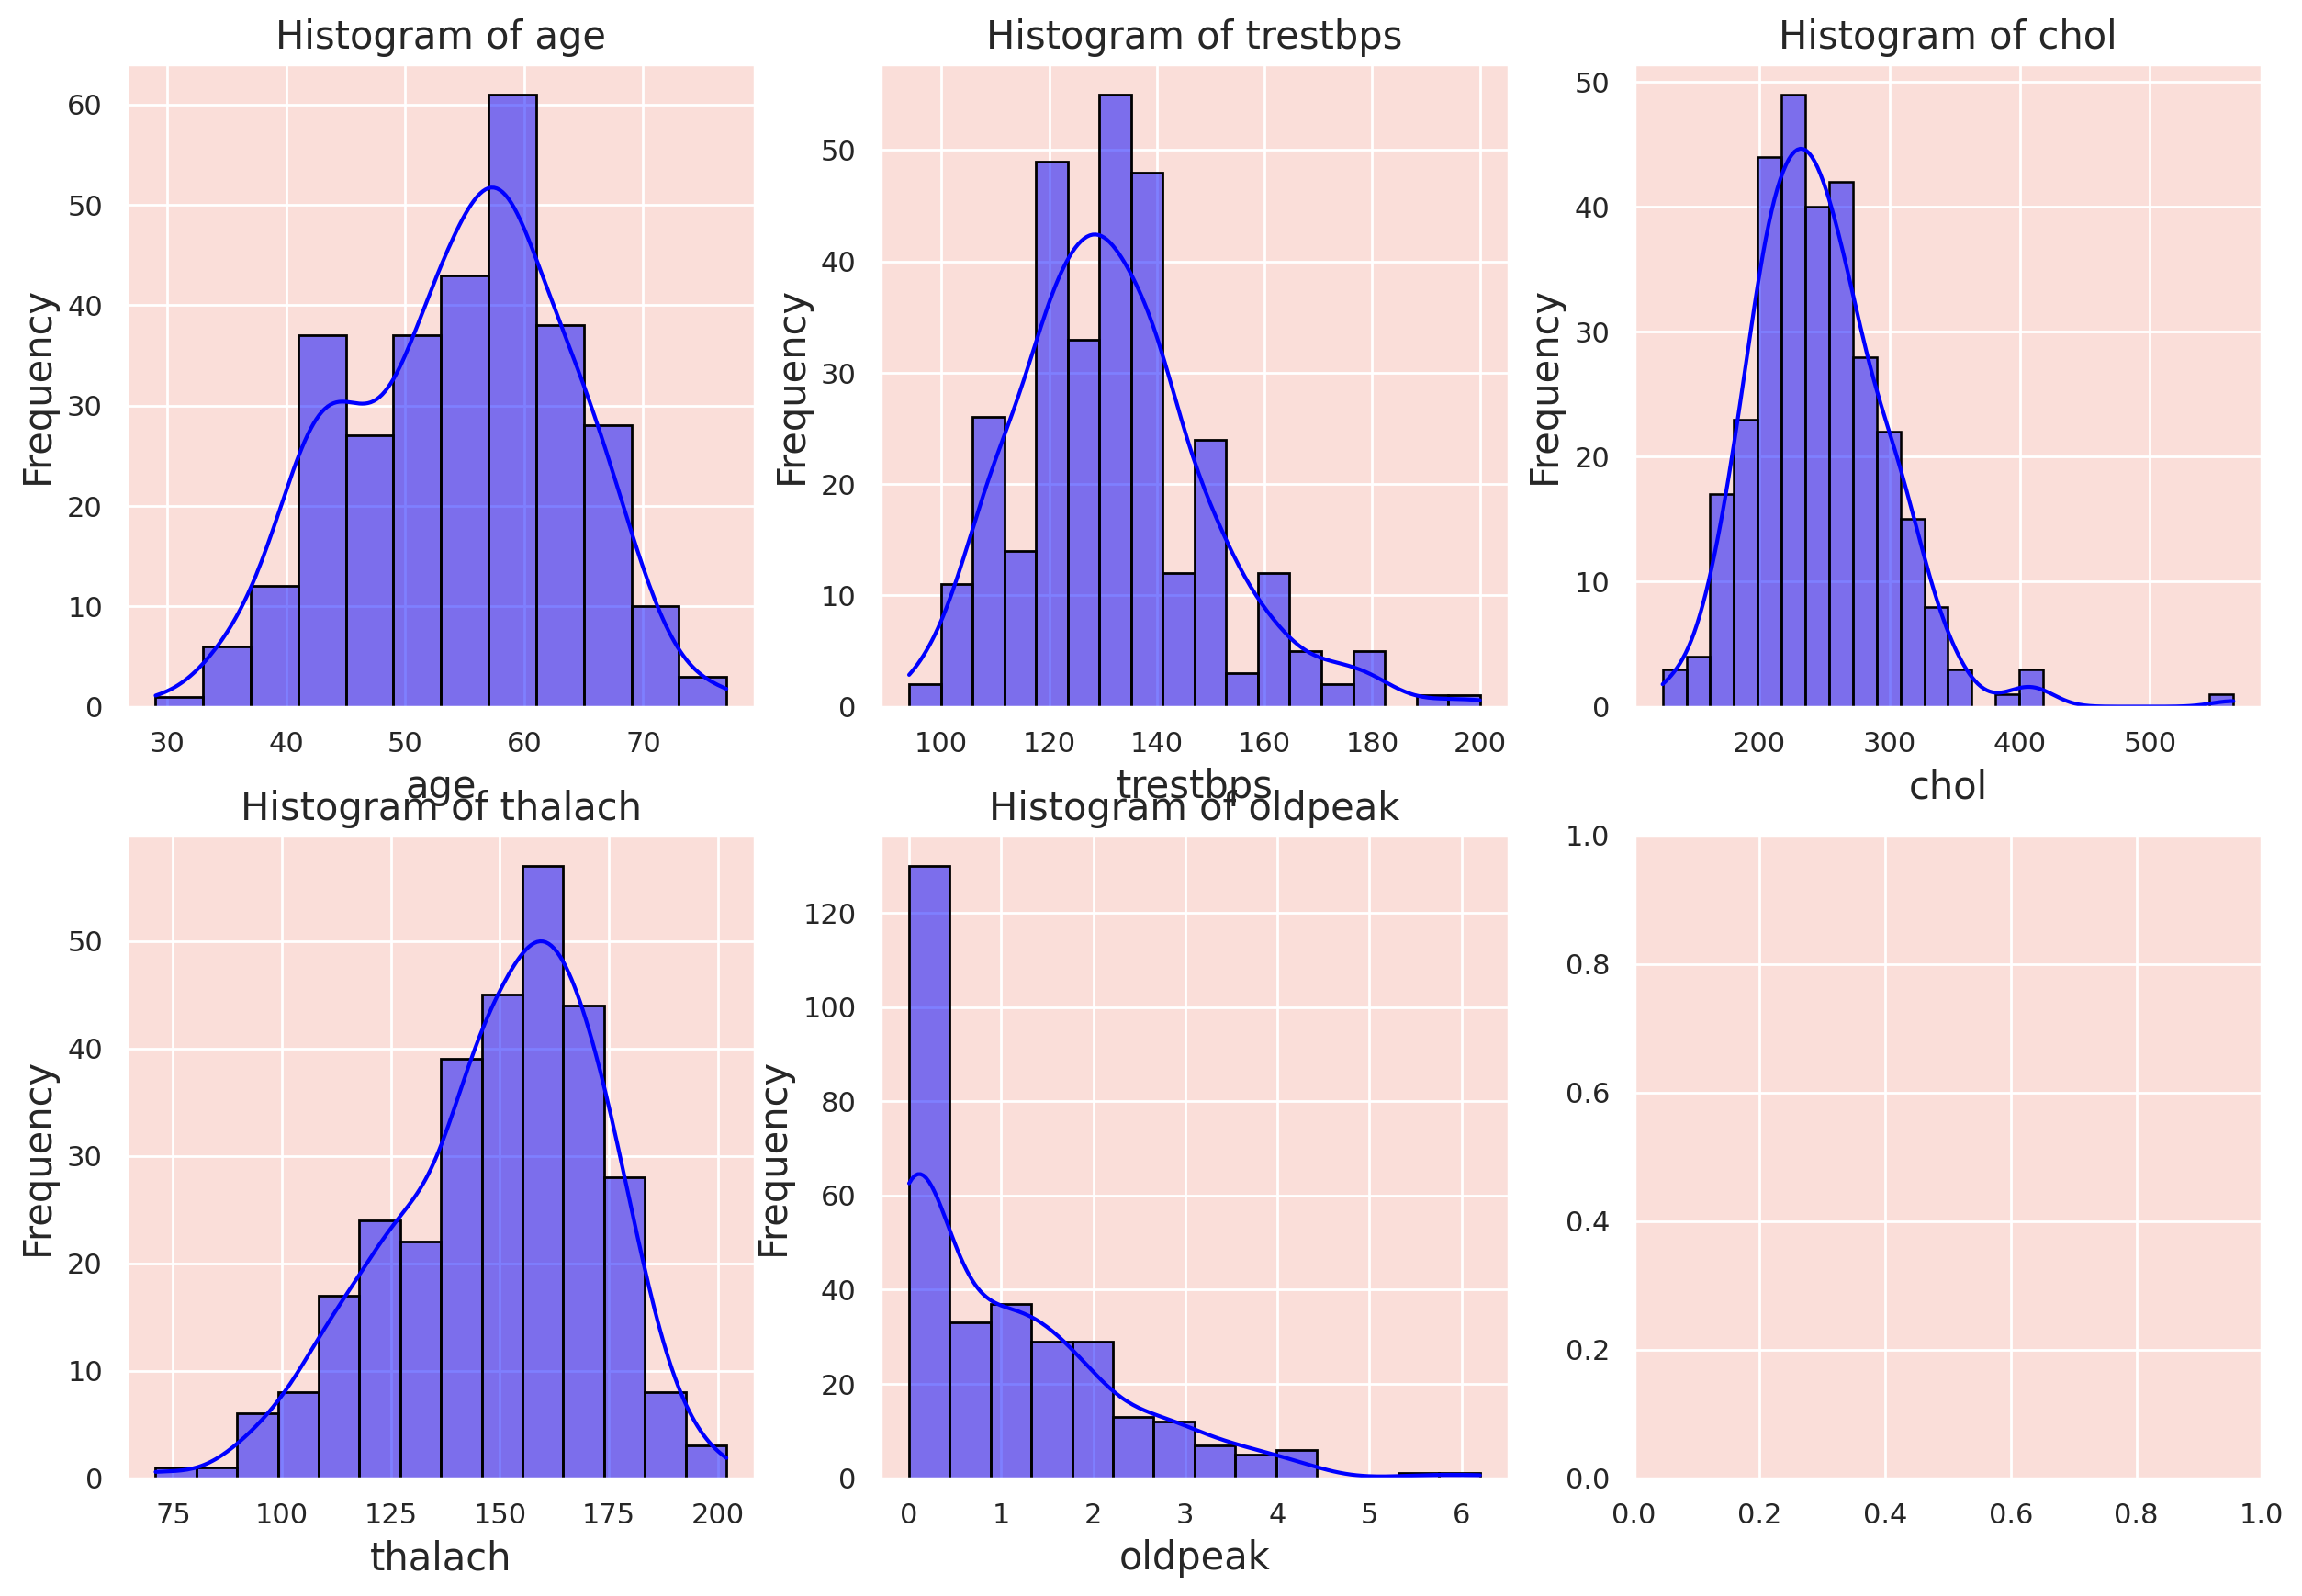

In [9]:
# Filter out continuous features for the univariate analysis
df_continuous = df[continuous_features]

#Setup subplots
fig,ax = plt.subplots(nrows=2, ncols=3,figsize=(15,10))

# creating histogram
for i, col in enumerate(df_continuous.columns):
    x = i // 3
    y = i % 3
    values, bin_edges = np.histogram(df_continuous[col], range=(np.floor(df_continuous[col].min()), df_continuous[col].max()), bins=30)

    graph = sns.histplot(data=df_continuous, x=col, kde=True, ax=ax[x, y], edgecolor='black', color='blue')
    ax[x, y].set_xlabel(col, fontsize=15)
    ax[x, y].set_ylabel('Frequency', fontsize=15)
    ax[x, y].set_title(f'Histogram of {col}', fontsize=15)


In [10]:
# Calculate and display the skewness for each continuous feature
print("Skewness of continuous features:")
print(df_continuous.skew())

Skewness of continuous features:
age        -0.202463
trestbps    0.713768
chol        1.143401
thalach    -0.537410
oldpeak     1.269720
dtype: float64


####From the histograms we can observe the distributions od the continuous variables. Age of the patients are more or less normally distributed. The resting blood pressure, levels are slightly positively skewed, whereas ST depression and cholestrol is strongly positively skewed. On the other hand Maximum heart rate achieved during stress is slightly negative skewed. The conclusions of the histograms are also shown numerically calculating the skewness

In [11]:
# Filtering out categorical variable
cat_features = [feature for feature in df.columns if feature not in continuous_features]
df_cat = df[cat_features]
df_cat

,sex,cp,fbs,restecg,exang,slope,ca,thal,target
0,1,3,1,0,0,0,0,1,1
1,1,2,0,1,0,0,0,2,1
2,0,1,0,0,0,2,0,2,1
3,1,1,0,1,0,2,0,2,1
4,0,0,0,1,1,2,0,2,1
...,...,...,...,...,...,...,...,...,...
298,0,0,0,1,1,1,0,3,0
299,1,3,0,1,0,1,0,3,0
300,1,0,1,1,0,1,2,3,0
301,1,0,0,1,1,1,1,3,0


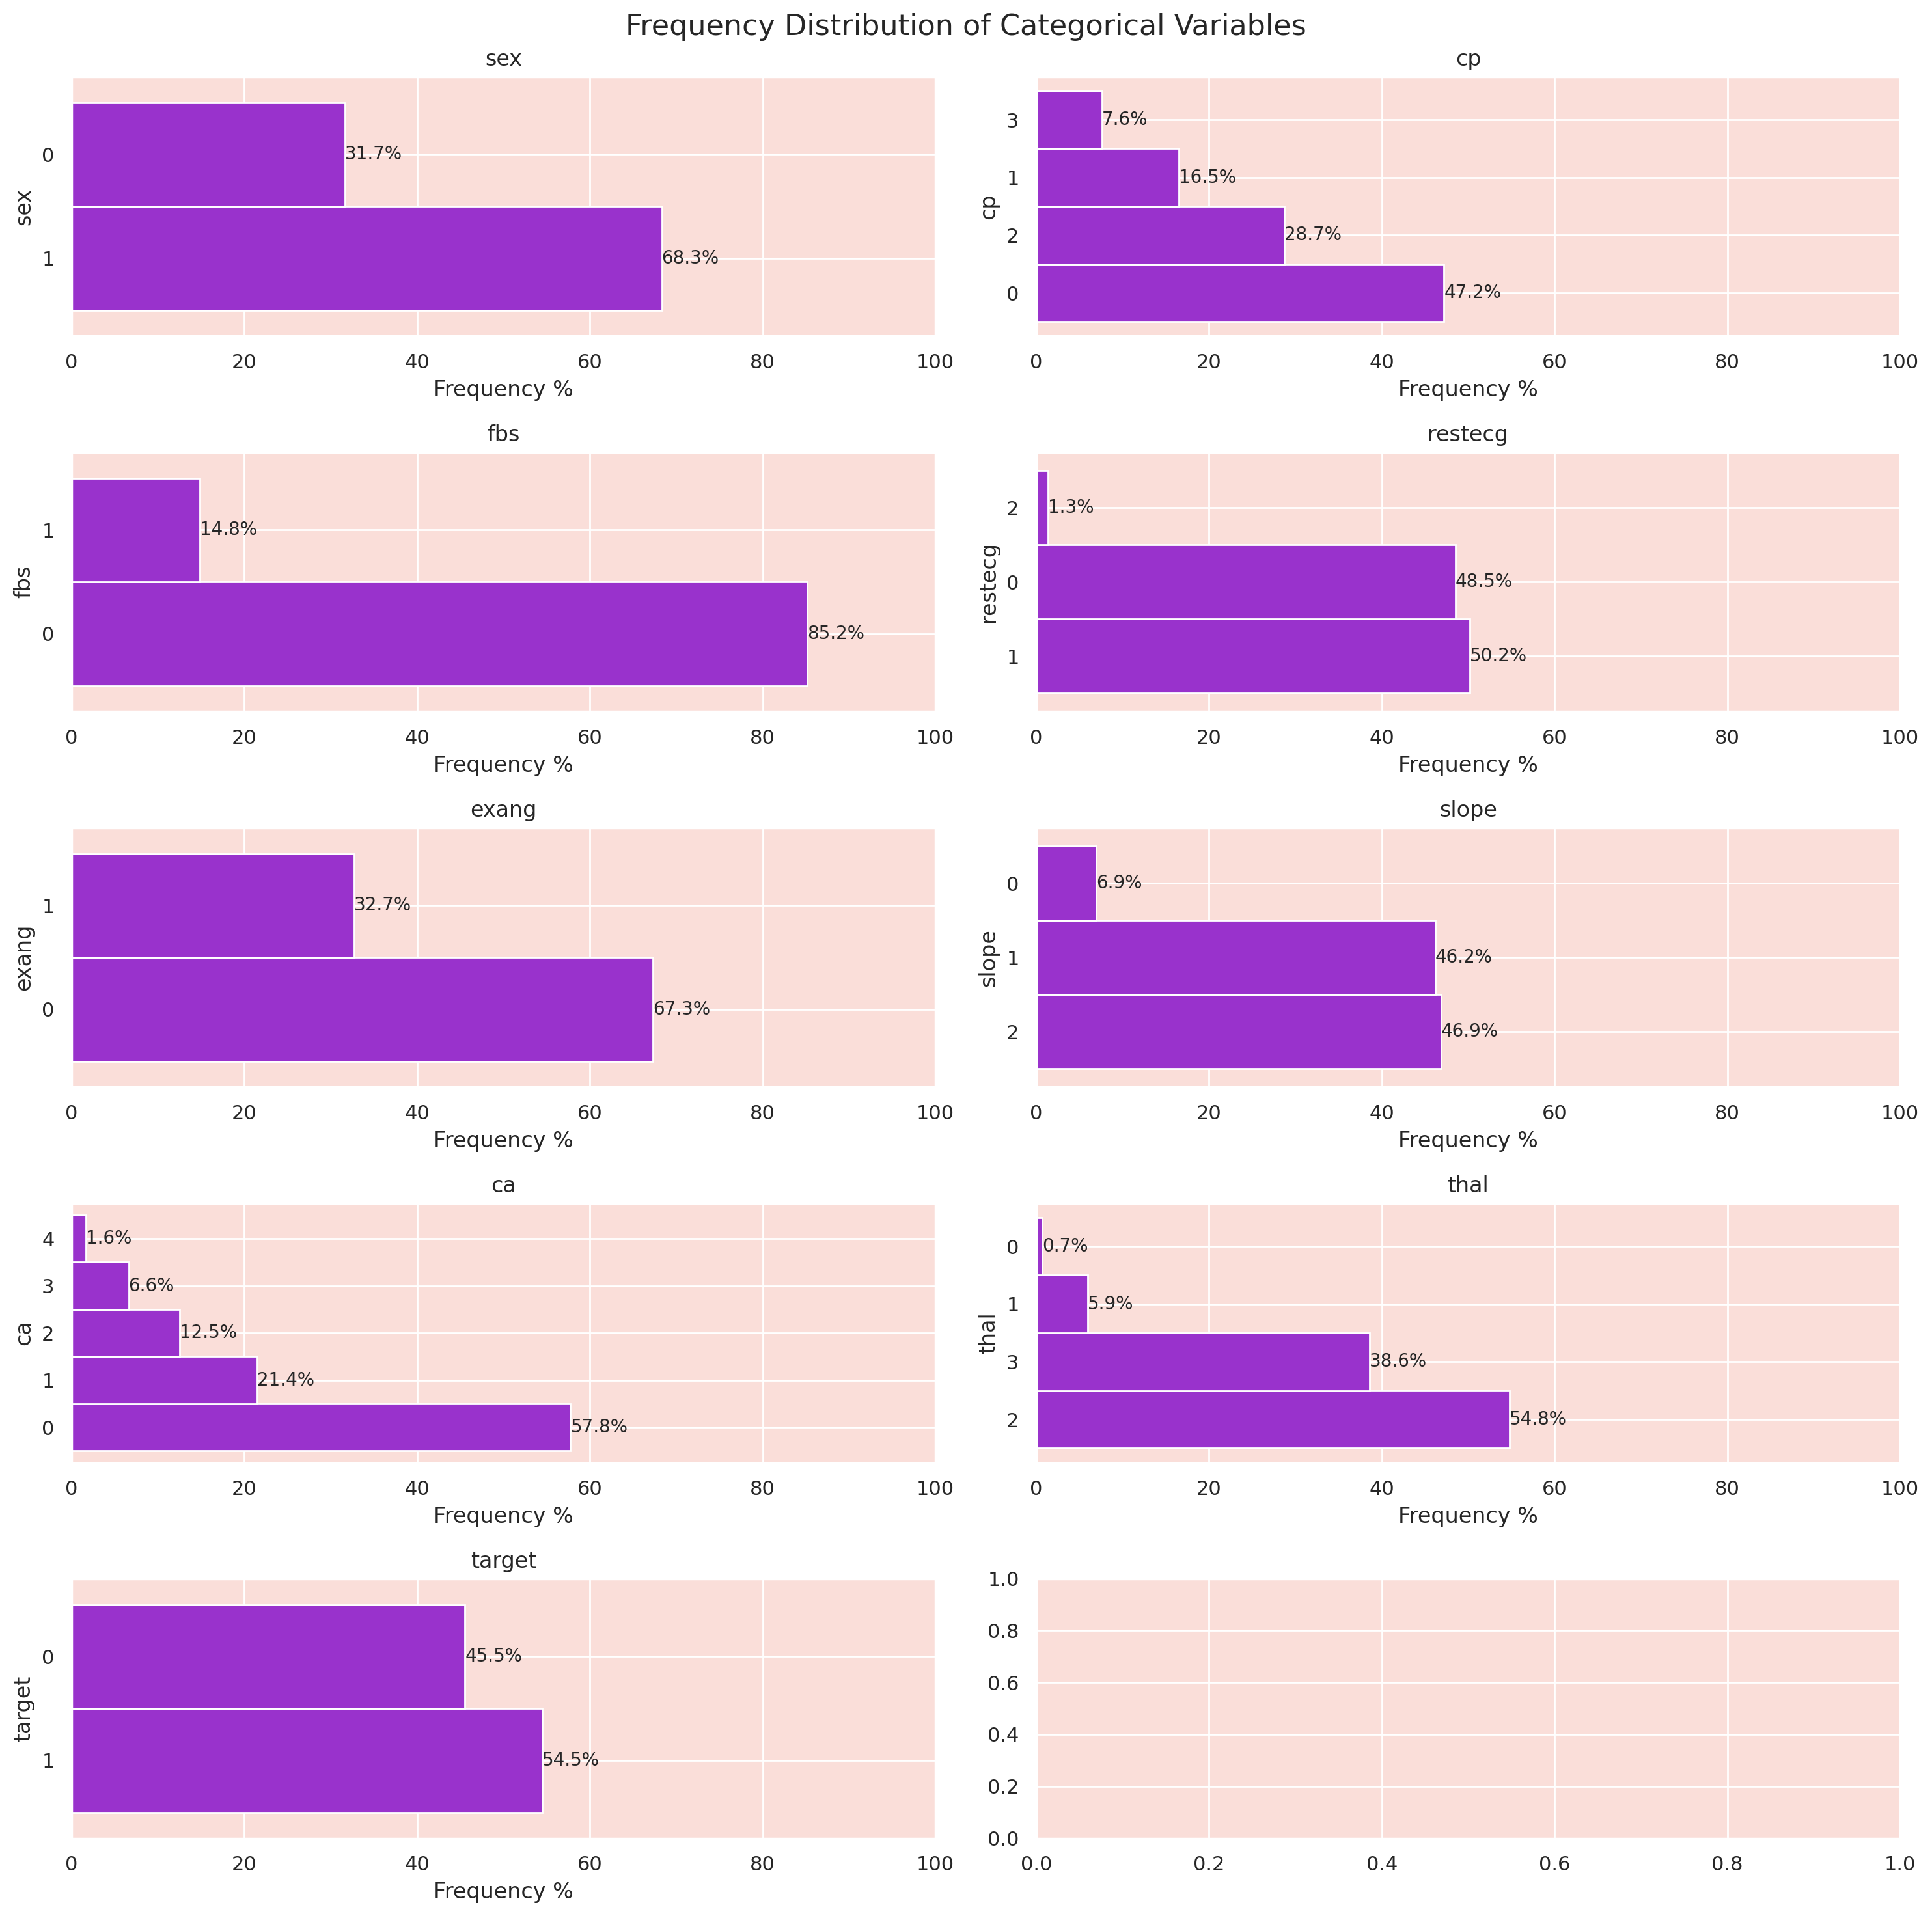

In [12]:
fig, ax = plt.subplots(nrows=5, ncols=2, figsize=(15, 15))
for i, col in enumerate(df_cat.columns):
    row = i // 2
    col_idx = i % 2

    value_counts = df[col].value_counts(normalize=True).mul(100).round(2).sort_values(ascending=False) # Calculating Frequency percentage
    value_counts.plot(kind='barh', ax=ax[row, col_idx], color='darkorchid', width=1)

    for index, value in enumerate(value_counts):
        ax[row, col_idx].text(value, index, f'{value:.1f}%', fontsize=10, va='center')


    ax[row, col_idx].set_xlim(0, 100)
    ax[row, col_idx].set_xlabel('Frequency %')
    ax[row, col_idx].set_title(f'{col}')

plt.suptitle('Frequency Distribution of Categorical Variables', fontsize=16)
plt.tight_layout()
plt.show()

####The above Horizontal bar graphs shows the frequency of each category for every categorical variable with their percentage of frequency.



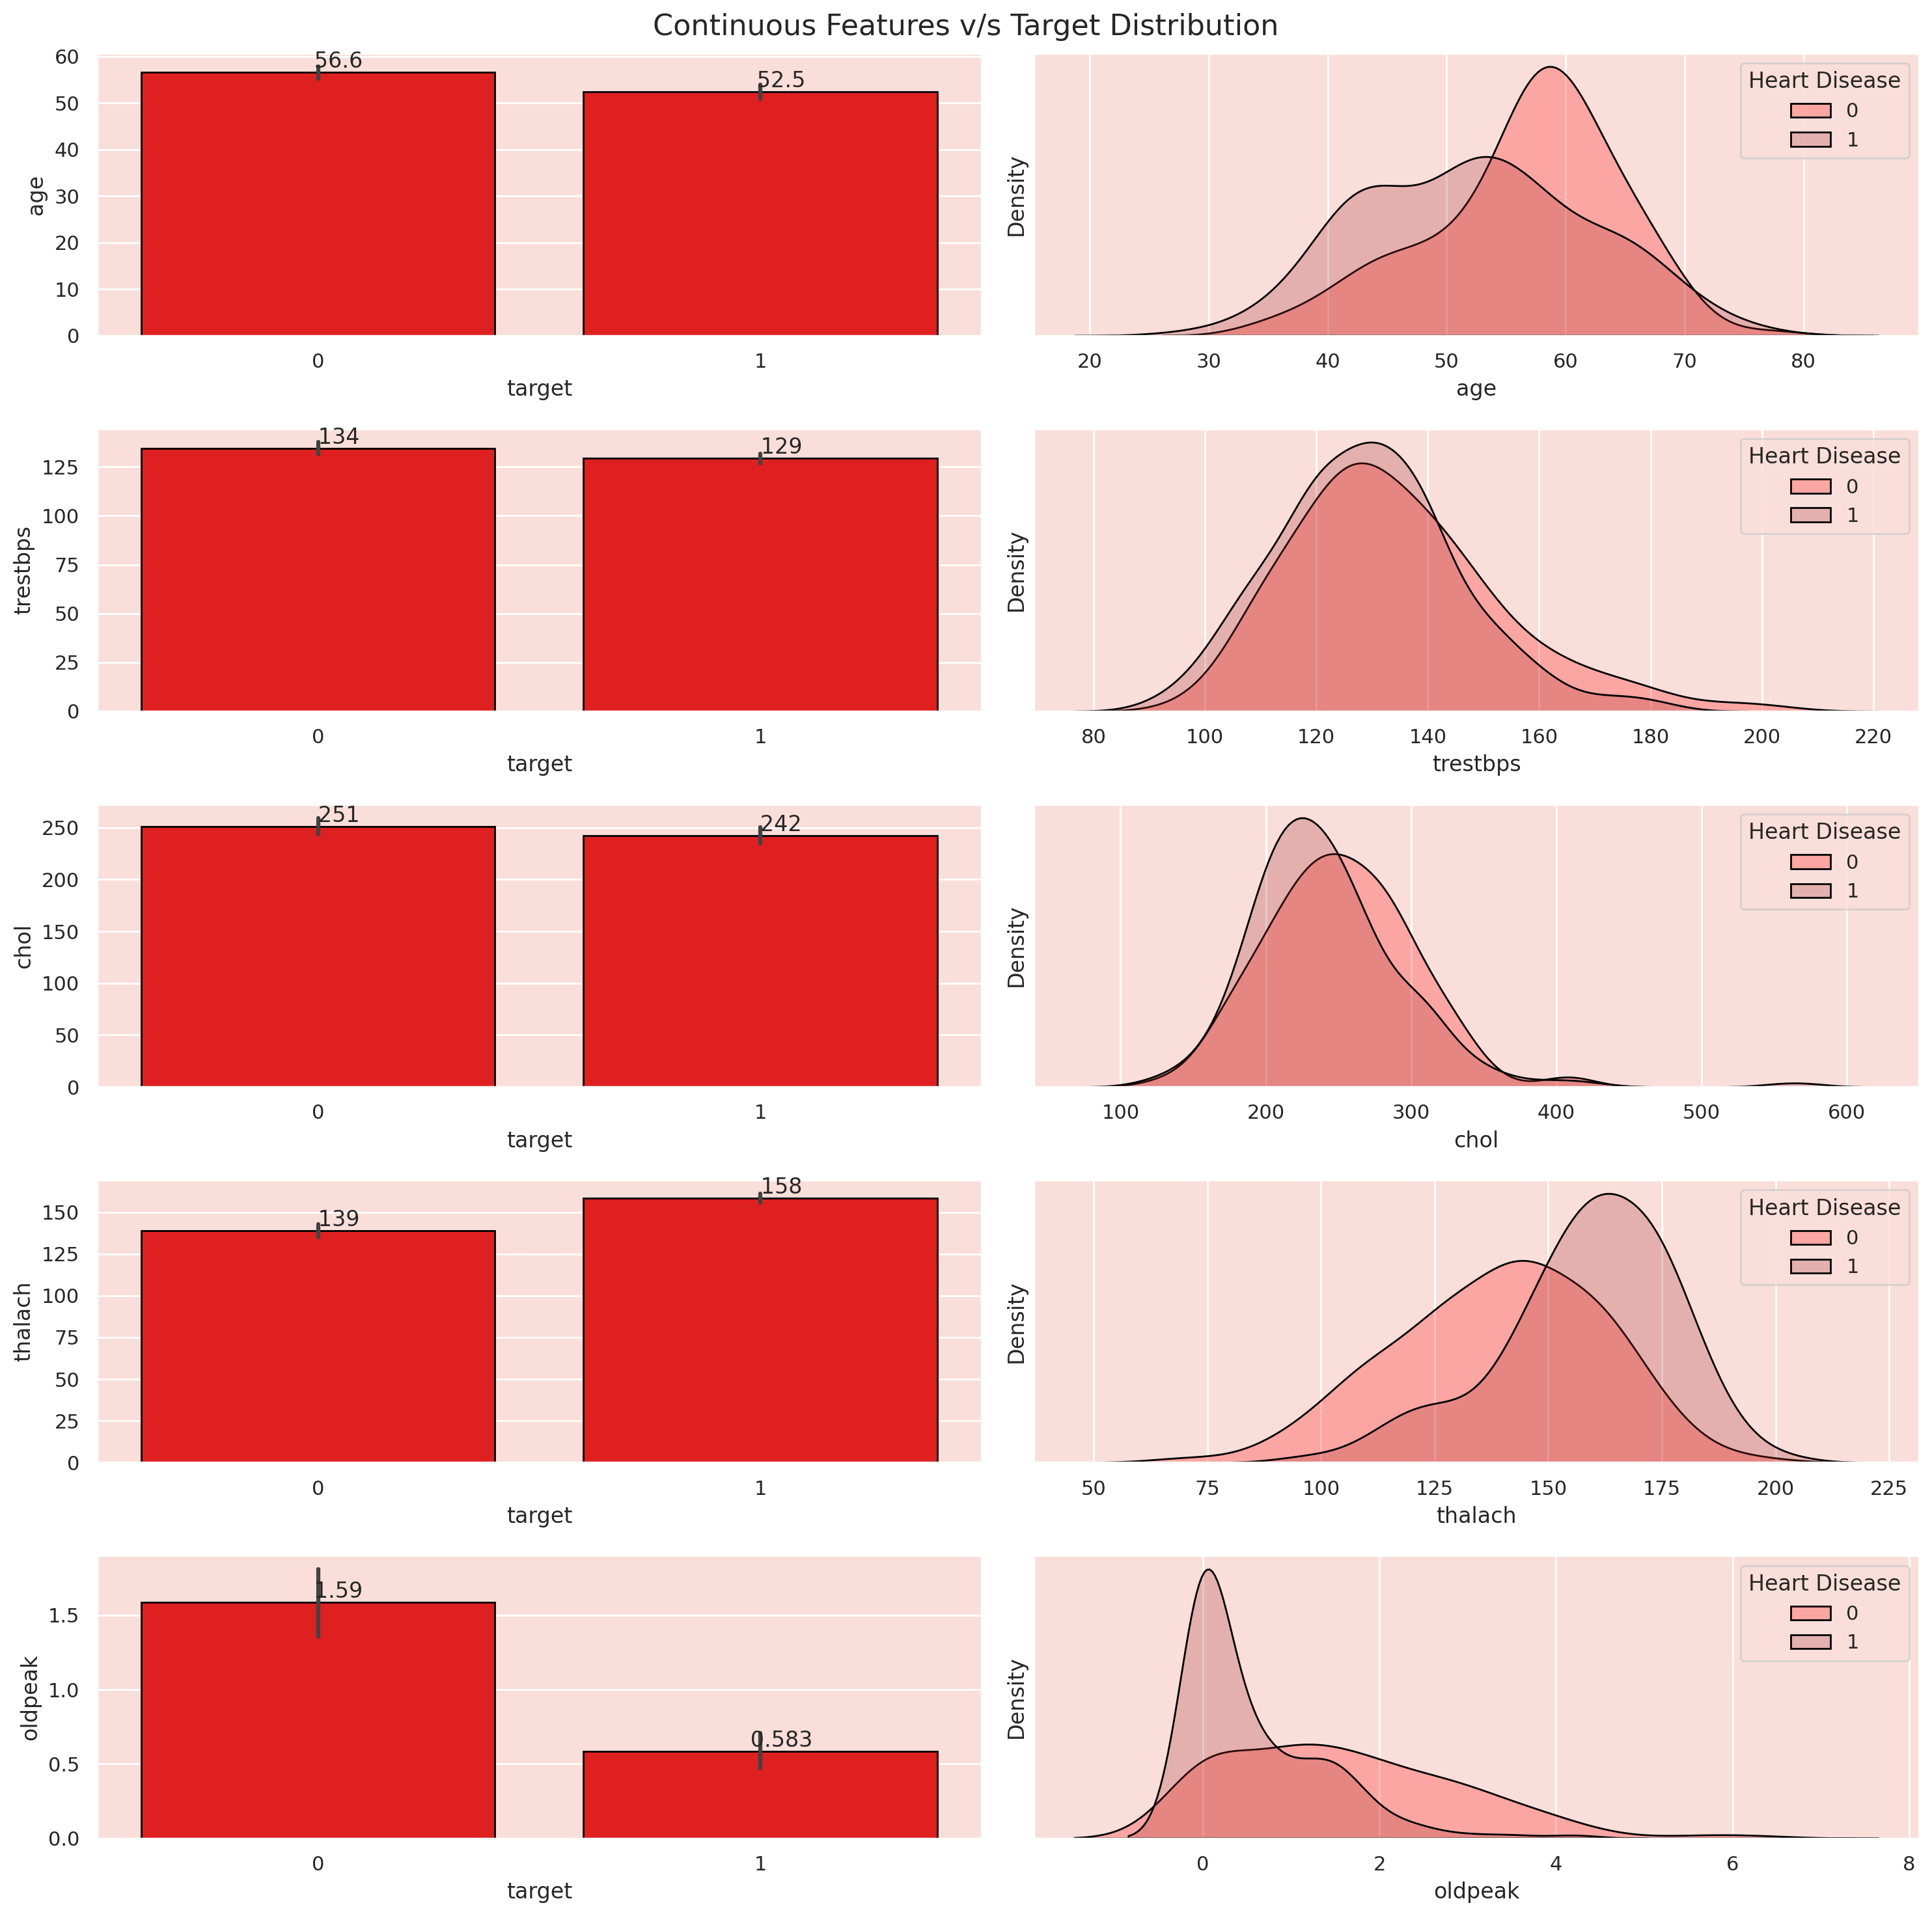

In [13]:
# Now we move on to bivariate analysis
# We shall visualize using bar plot and KDE plot

sns.set_palette(['red', 'brown'])
fig, ax = plt.subplots(len(continuous_features), ncols=2, figsize=(15, 15))

# Creating bar graph
for i, col in enumerate(continuous_features):
    graph = sns.barplot(data=df, x='target', y=col, ax=ax[i, 0], edgecolor='black')

    #KDE plot showing dist of the feature for each target category
    sns.kdeplot(data=df[df["target"]==0], x=col, ax=ax[i, 1], fill=True, edgecolor='black', label = '0')
    sns.kdeplot(data=df[df["target"]==1], x=col, ax=ax[i, 1], fill=True, edgecolor='black', label = '1')
    ax[i, 1].set_yticks([])
    ax[i, 1].legend(title='Heart Disease', loc='upper right')

    for cont in graph.containers:
        graph.bar_label(cont, fmt='      %.3g')

plt.suptitle('Continuous Features v/s Target Distribution', fontsize=16)
plt.tight_layout()
plt.show()

####The above diagram panel shows the mean value of every continuous variable with respect to target category whether thye patient has heart disease or not through the bar graphs. on the right hand side the distribution of the continuous variables are shown for seperate 2 category

*   After observing the age variable it can be concluded that most of the patients with heart disease are of lower age
*   Further we can say patients with higher heart rate during stress test are more prone to have a heart disease.







> ***Data Preprocessing***













On keenly observing we find no features irrelevant in order to impose any training model. So we keep all the features intact.

In [14]:
df.isnull().sum().sum()

np.int64(0)

As shown earlier no missing values are present in the data.

###--> Outlier Treatment

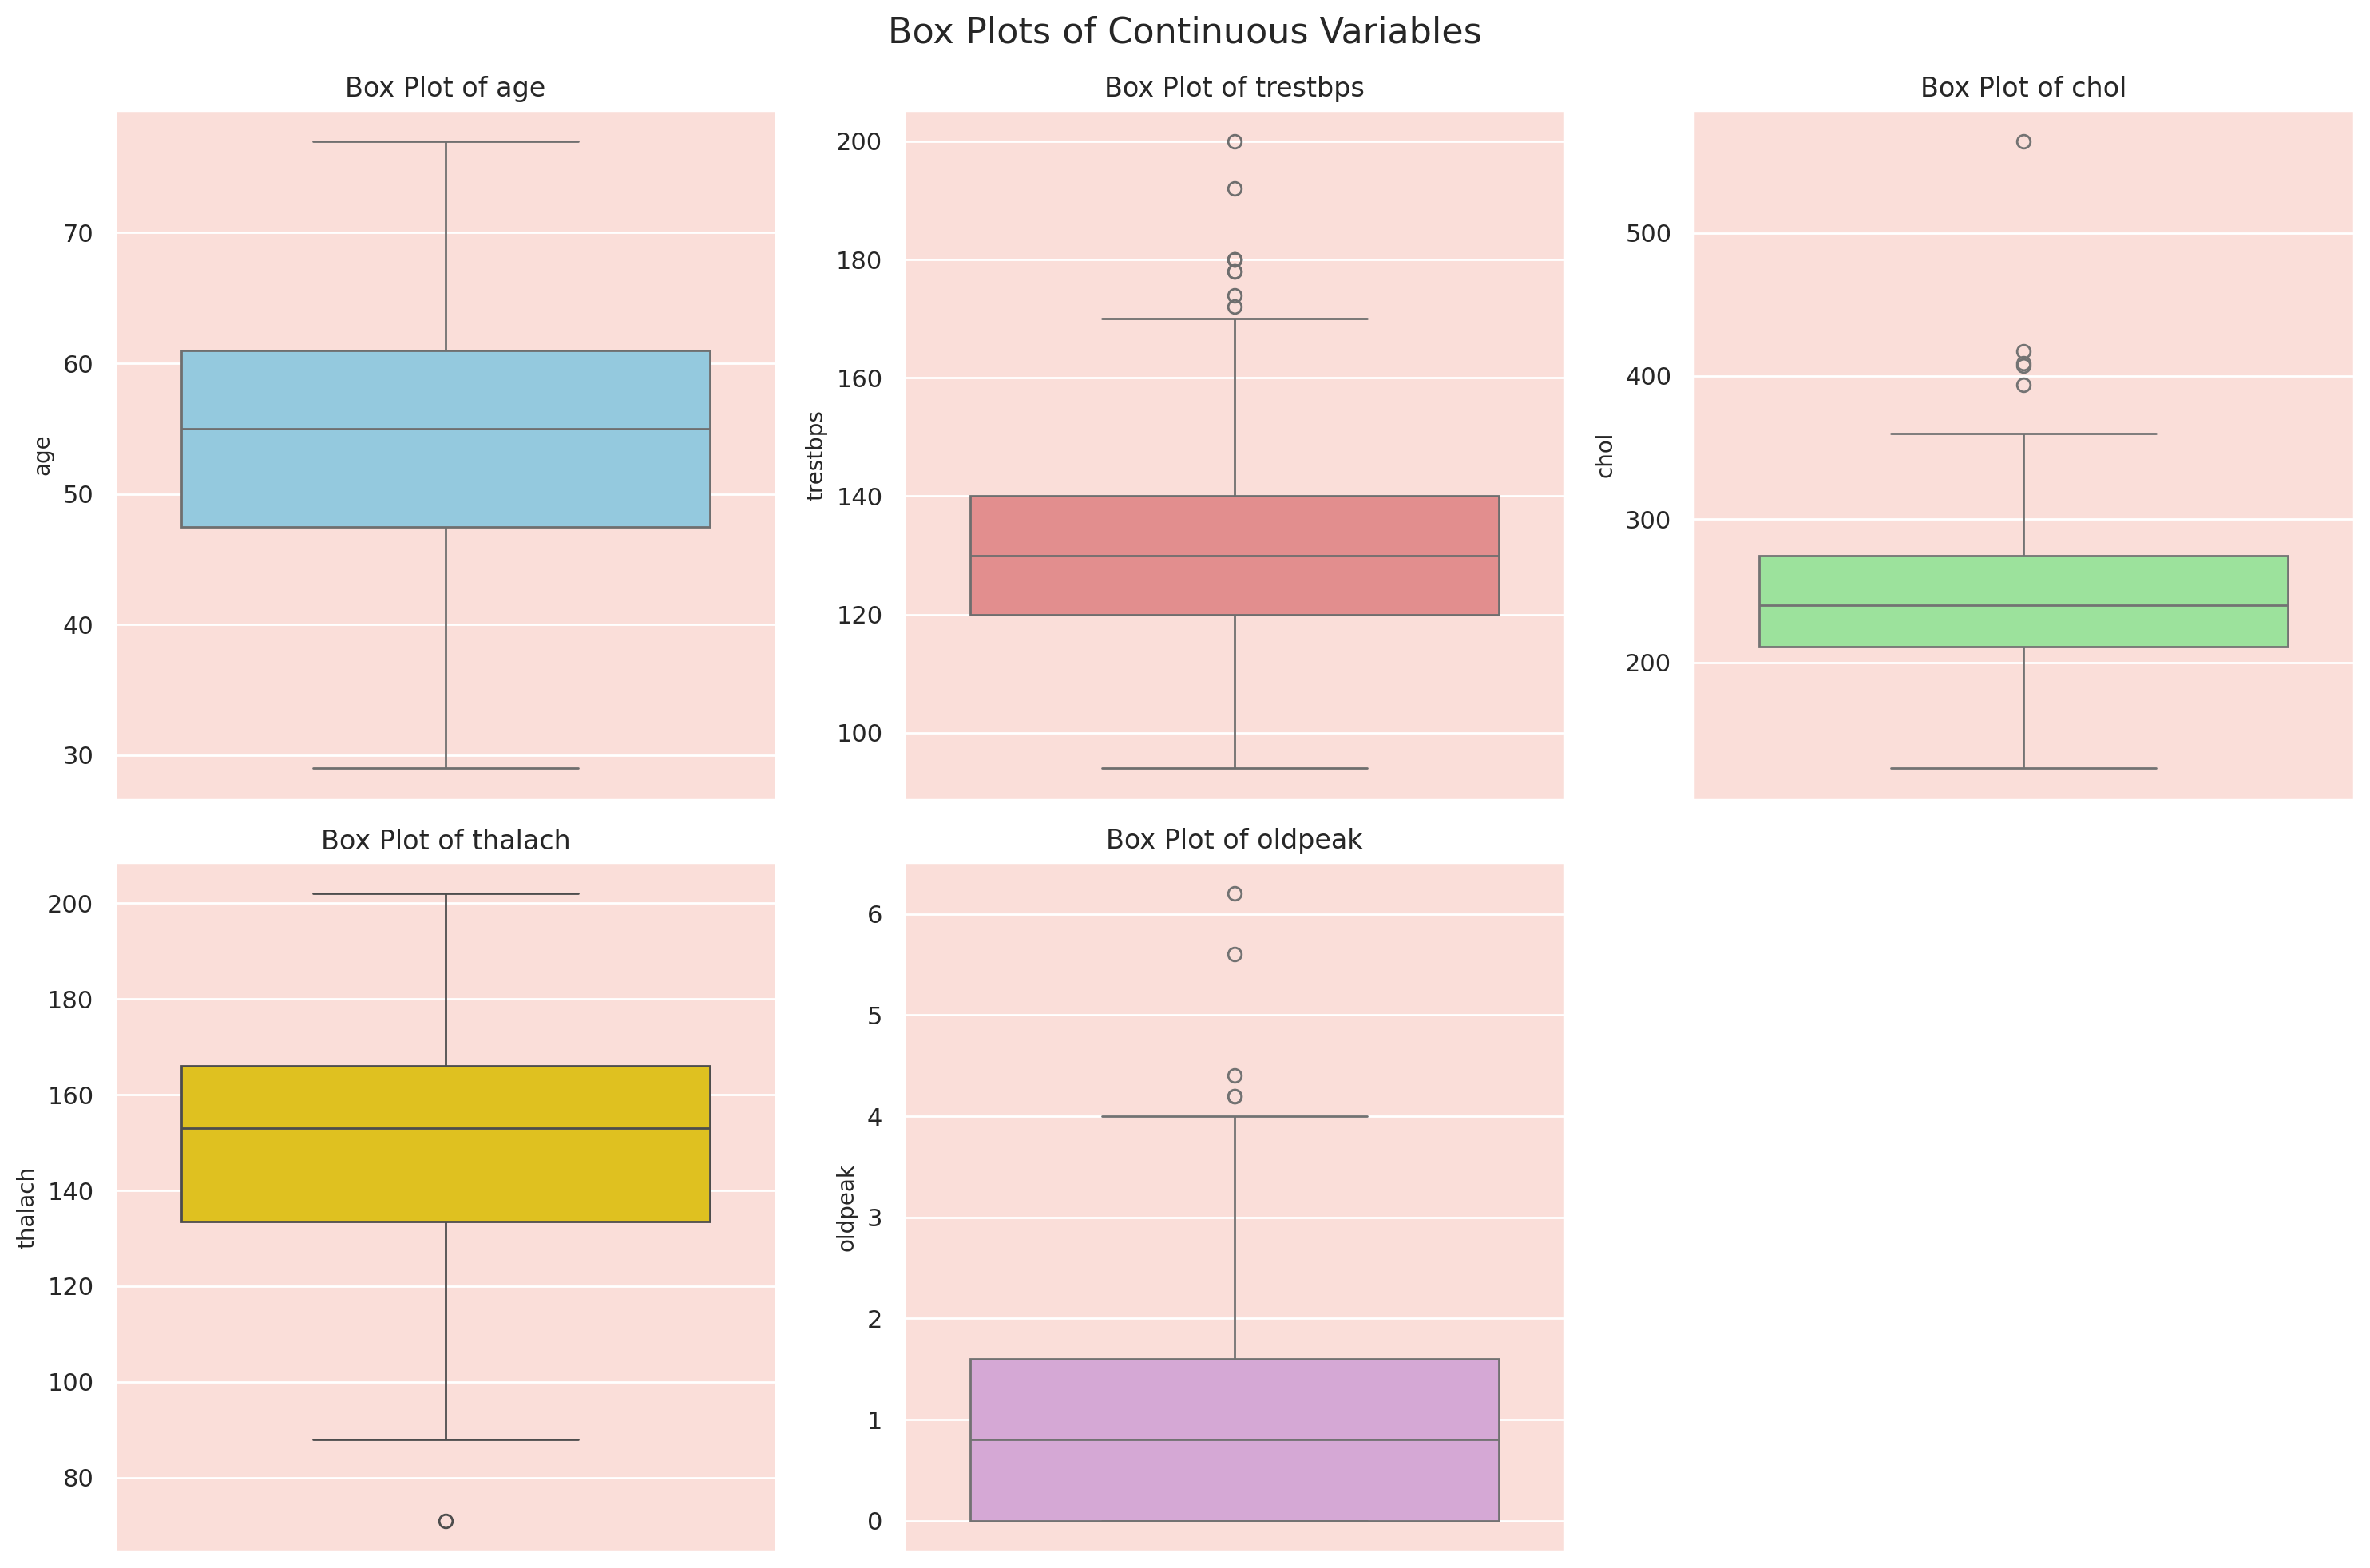

In [15]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
ax = ax.flatten() # Flatten the 2x3 array of axes for easy iteration

colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum']

for i, col in enumerate(continuous_features):
    # Create a box plot for each continuous variable
    sns.boxplot(y=df[col], ax=ax[i], color=colors[i])
    ax[i].set_title(f'Box Plot of {col}', fontsize=12)
    ax[i].set_ylabel(col, fontsize=10)
    ax[i].set_xlabel('')
# Hide any unused subplots if there are fewer continuous features than subplots
for j in range(len(continuous_features), len(ax)):
    fig.delaxes(ax[j])

plt.suptitle('Box Plots of Continuous Variables', fontsize=16) # Overall title for the figure
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

To visualise the condition of outliers for each continuous variable we use boxplots for each continuous category. The dots above or bellow the whiskers of the box plot shows the number of outliers present in their respective category.

In [16]:
# Calculating 1st Quartile and 3rd Quaetile
Q1 = df[continuous_features].quantile(0.25)
Q3 = df[continuous_features].quantile(0.75)
IQR = Q3 - Q1
print("IQR of the continuous features are:\n", IQR)

IQR of the continuous features are:
 age         13.5
trestbps    20.0
chol        63.5
thalach     32.5
oldpeak      1.6
dtype: float64


In [17]:
# Calculating the outliers
outliers = ((df[continuous_features] < (Q1 - 1.5 * IQR)) | (df[continuous_features] > (Q3 + 1.5 * IQR))).sum()
print ("Number of outliers present in the dataset for each continuous variable are")
outliers

Number of outliers present in the dataset for each continuous variable are


,0
age,0
trestbps,9
chol,5
thalach,1
oldpeak,5


The dataset is quite small and the total no of outliers are 20. So we cannot simply drop them and proceed. We shall scale the data later on.

###-->Transforming Skewed Features

In [18]:
# creating Dummy variables
df_encoded = pd.get_dummies(df, columns=['cp', 'restecg', 'thal'], drop_first=True)

features_to_convert = ['sex', 'fbs', 'exang', 'slope', 'ca', 'target']
# Add the newly created boolean dummy columns to the list for conversion to int
boolean_cols = ['cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'thal_1', 'thal_2', 'thal_3']
features_to_convert.extend(boolean_cols)

for feature in features_to_convert:
    df_encoded[feature] = df_encoded[feature].astype(int)

df_encoded.dtypes

,0
age,int64
sex,int64
trestbps,int64
chol,int64
fbs,int64
thalach,int64
exang,int64
oldpeak,float64
slope,int64
ca,int64


In [19]:
df_encoded.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,63,1,145,233,1,150,0,2.3,0,0,1,0,0,1,0,0,1,0,0
1,37,1,130,250,0,187,0,3.5,0,0,1,0,1,0,1,0,0,1,0
2,41,0,130,204,0,172,0,1.4,2,0,1,1,0,0,0,0,0,1,0
3,56,1,120,236,0,178,0,0.8,2,0,1,1,0,0,1,0,0,1,0
4,57,0,120,354,0,163,1,0.6,2,0,1,0,0,0,1,0,0,1,0


In [20]:
# First we describe x and y then split the data
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

In [21]:
#Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

In [22]:
X_train.shape, X_test.shape

((242, 18), (61, 18))

For boxcox transformation all data are required to be strictly positive. To transform the oldpeak feature we add a small constant to ensure every obs are strictly greater than 0.

In [23]:
X_train['oldpeak'] = X_train['oldpeak'] + 0.0001
X_test['oldpeak'] = X_test['oldpeak'] + 0.0001

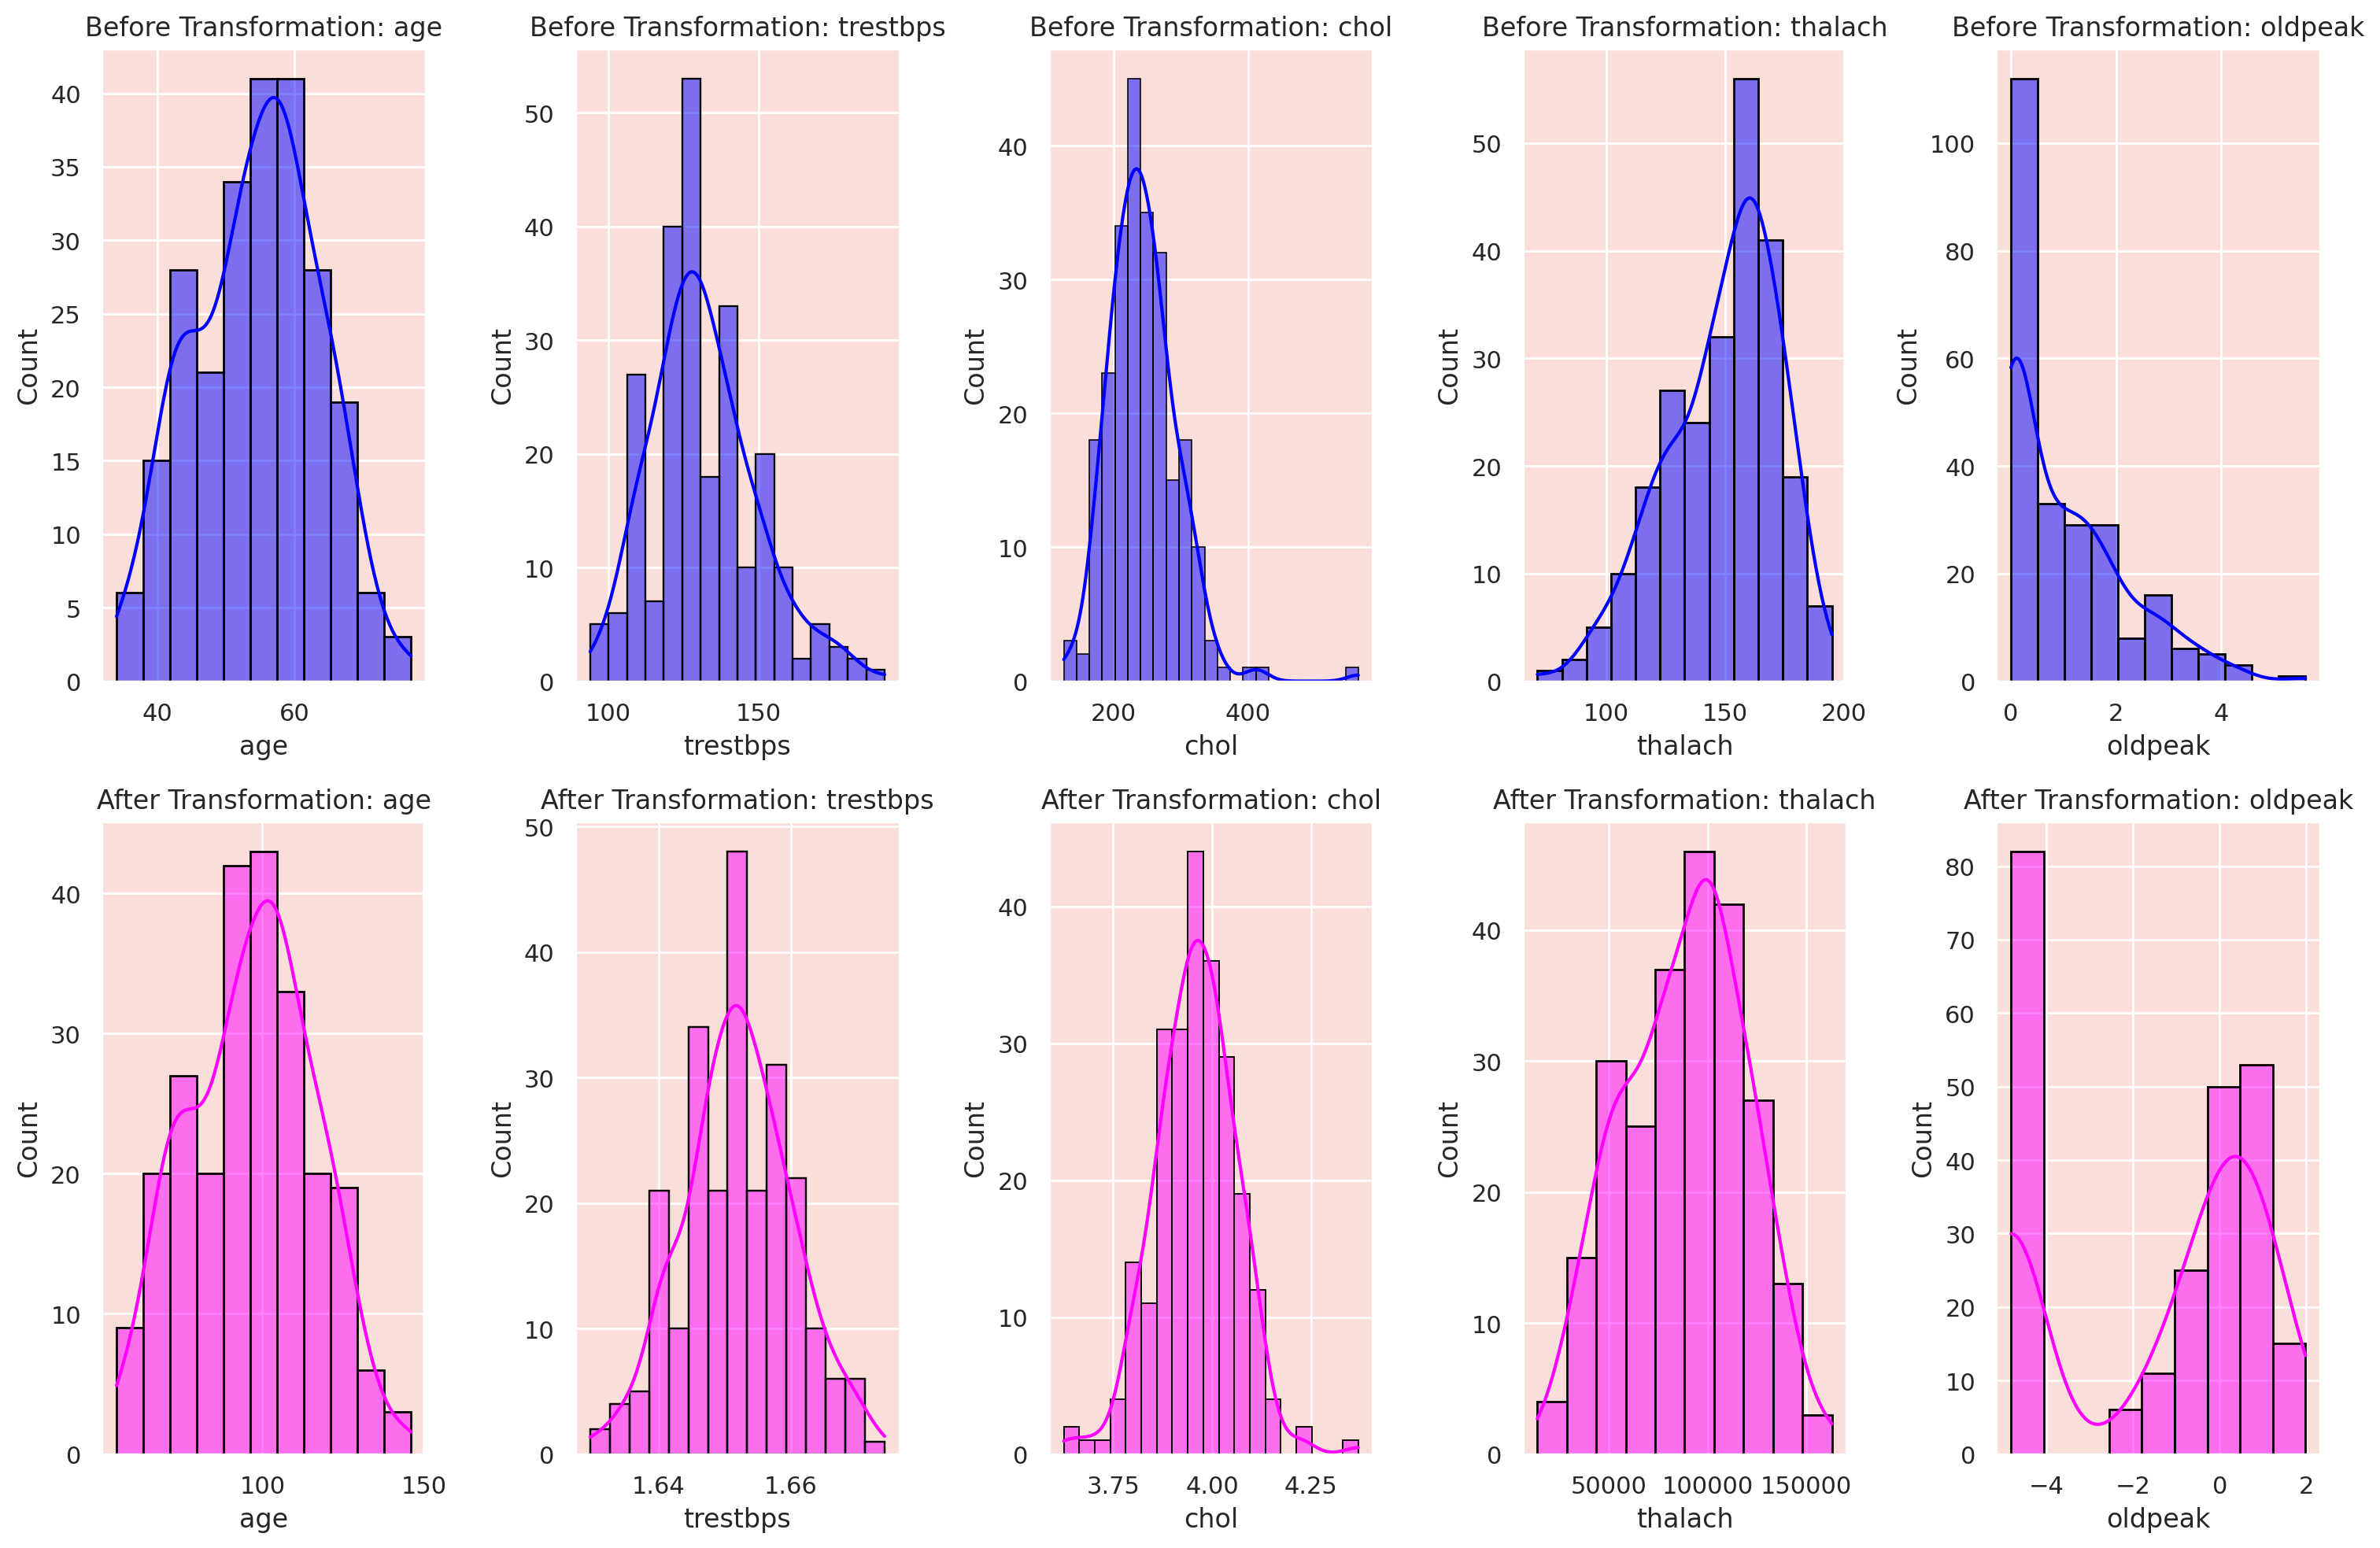

In [24]:
#Now we shall transform the data and compare it with before transformation
fig, ax = plt.subplots(2, 5, figsize=(15, 10))

for i, col in enumerate(continuous_features):
    sns.histplot(X_train[col], kde=True, ax=ax[0, i], edgecolor='black', color='blue').set_title(f'Before Transformation: {col}')


#Applying Box-cox Transformation
lambdas = {}
for i, col in enumerate(continuous_features):
  if X_train[col].min() > 0:
    X_train[col], lambdas[col] = boxcox(X_train[col])
    X_test[col] = boxcox(X_test[col], lmbda=lambdas[col])
    sns.histplot(X_train[col], kde=True, ax=ax[1, i], edgecolor='black', color='magenta').set_title(f'After Transformation: {col}')
  else:
    sns.histplot(X_train[col], kde=True, ax=ax[1, i], edgecolor='black', color='magenta').set_title(f'After Transformation: {col}')

plt.tight_layout()
plt.show()

In [25]:
# Checking the skewness
print("\nSkewness of continuous features in X_test after transformation:")
print(X_test[continuous_features].skew())


Skewness of continuous features in X_test after transformation:
age        -0.465915
trestbps    0.261241
chol       -0.114262
thalach     0.404061
oldpeak    -0.713758
dtype: float64


After the Box-Cox transformation the continuous variables became more or less normally distributed or more symmetric

In [26]:
X_train.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
269,99.775363,1,1.652121,4.044511,1,34193.227632,1,0.488153,0,0,0,0,0,0,0,0,0,1
191,104.060287,1,1.651135,3.909224,0,61564.640490,1,0.840279,1,3,0,0,0,0,0,0,0,1
15,87.096593,0,1.646937,3.916243,0,97354.894861,0,0.488153,1,0,0,1,0,1,0,0,1,0
224,95.519188,1,1.641028,3.960431,0,55975.891019,1,1.119112,1,1,0,0,0,1,0,0,0,1
250,89.190732,1,1.656716,4.069855,0,51729.486474,1,1.612805,1,3,0,0,0,1,0,0,0,1


##**Decision Tree Model Building**

In [27]:
# Defining the base DT model
dt_base = DecisionTreeClassifier(random_state=0)

In medical cases, it is important to have high recall for positive class, i.e., all the future patients having a heart disease must be identified without fail. If a patient having heart disease is identified to be fit, the outcome may be very fatal as the decision would be not to keep that patient under medication. So, it is very necessary to capture the patients acctualy having heart disease, i.e., we must ensure high recall for positive class.

####So we establish a function to determine the optimal set of hyperparameters that yield highest recall for the model.

In [28]:
def tune_clf_hyperparameters(clf, param_grid, X_train, y_train, scoring='recall', n_splits=3):

    #Creating the cross validation object to ensure the class dist is the same across all the folds
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    clf_grid = GridSearchCV(clf, param_grid, cv=cv, scoring=scoring, n_jobs=-1)
    # Fitting the GridSearch object to the training data
    clf_grid.fit(X_train, y_train)
    best_hyperparameters = clf_grid.best_params_

    return clf_grid.best_estimator_, best_hyperparameters

In [29]:
# Hyperparameter grid for DT
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2,3],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1,2]}
# Giving choices to the machine among which I need the best one

In [30]:
# Calling parameters for hyperparameter tuning
dt_best, dt_best_params = tune_clf_hyperparameters(dt_base, param_grid_dt, X_train, y_train)
print ('Decision Tree Optimal Hyperparameters')
dt_best_params

Decision Tree Optimal Hyperparameters


{'criterion': 'entropy',
 'max_depth': 2,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

####Through this process best choices of criteria, max depth, minimum sample leaf and split is given for ensuring the highest recall score. Now we shall evaluate the model on this basis.

In [31]:
# Evaluating the optimised model in training model
print(classification_report(y_train, dt_best.predict(X_train)))

              precision    recall  f1-score   support

           0       0.73      0.75      0.74       110
           1       0.78      0.77      0.78       132

    accuracy                           0.76       242
   macro avg       0.76      0.76      0.76       242
weighted avg       0.76      0.76      0.76       242



In [32]:
# Evaluating the optimised model in testing model
print(classification_report(y_test, dt_best.predict(X_test)))

              precision    recall  f1-score   support

           0       0.80      0.71      0.75        28
           1       0.78      0.85      0.81        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61



Here we get the recall score for positive class in testing data as 85%. This means out of 100 patients with heart disease the model predicts 85 times correctly, which is not a bad figure, but we will still compare it with other ML model.

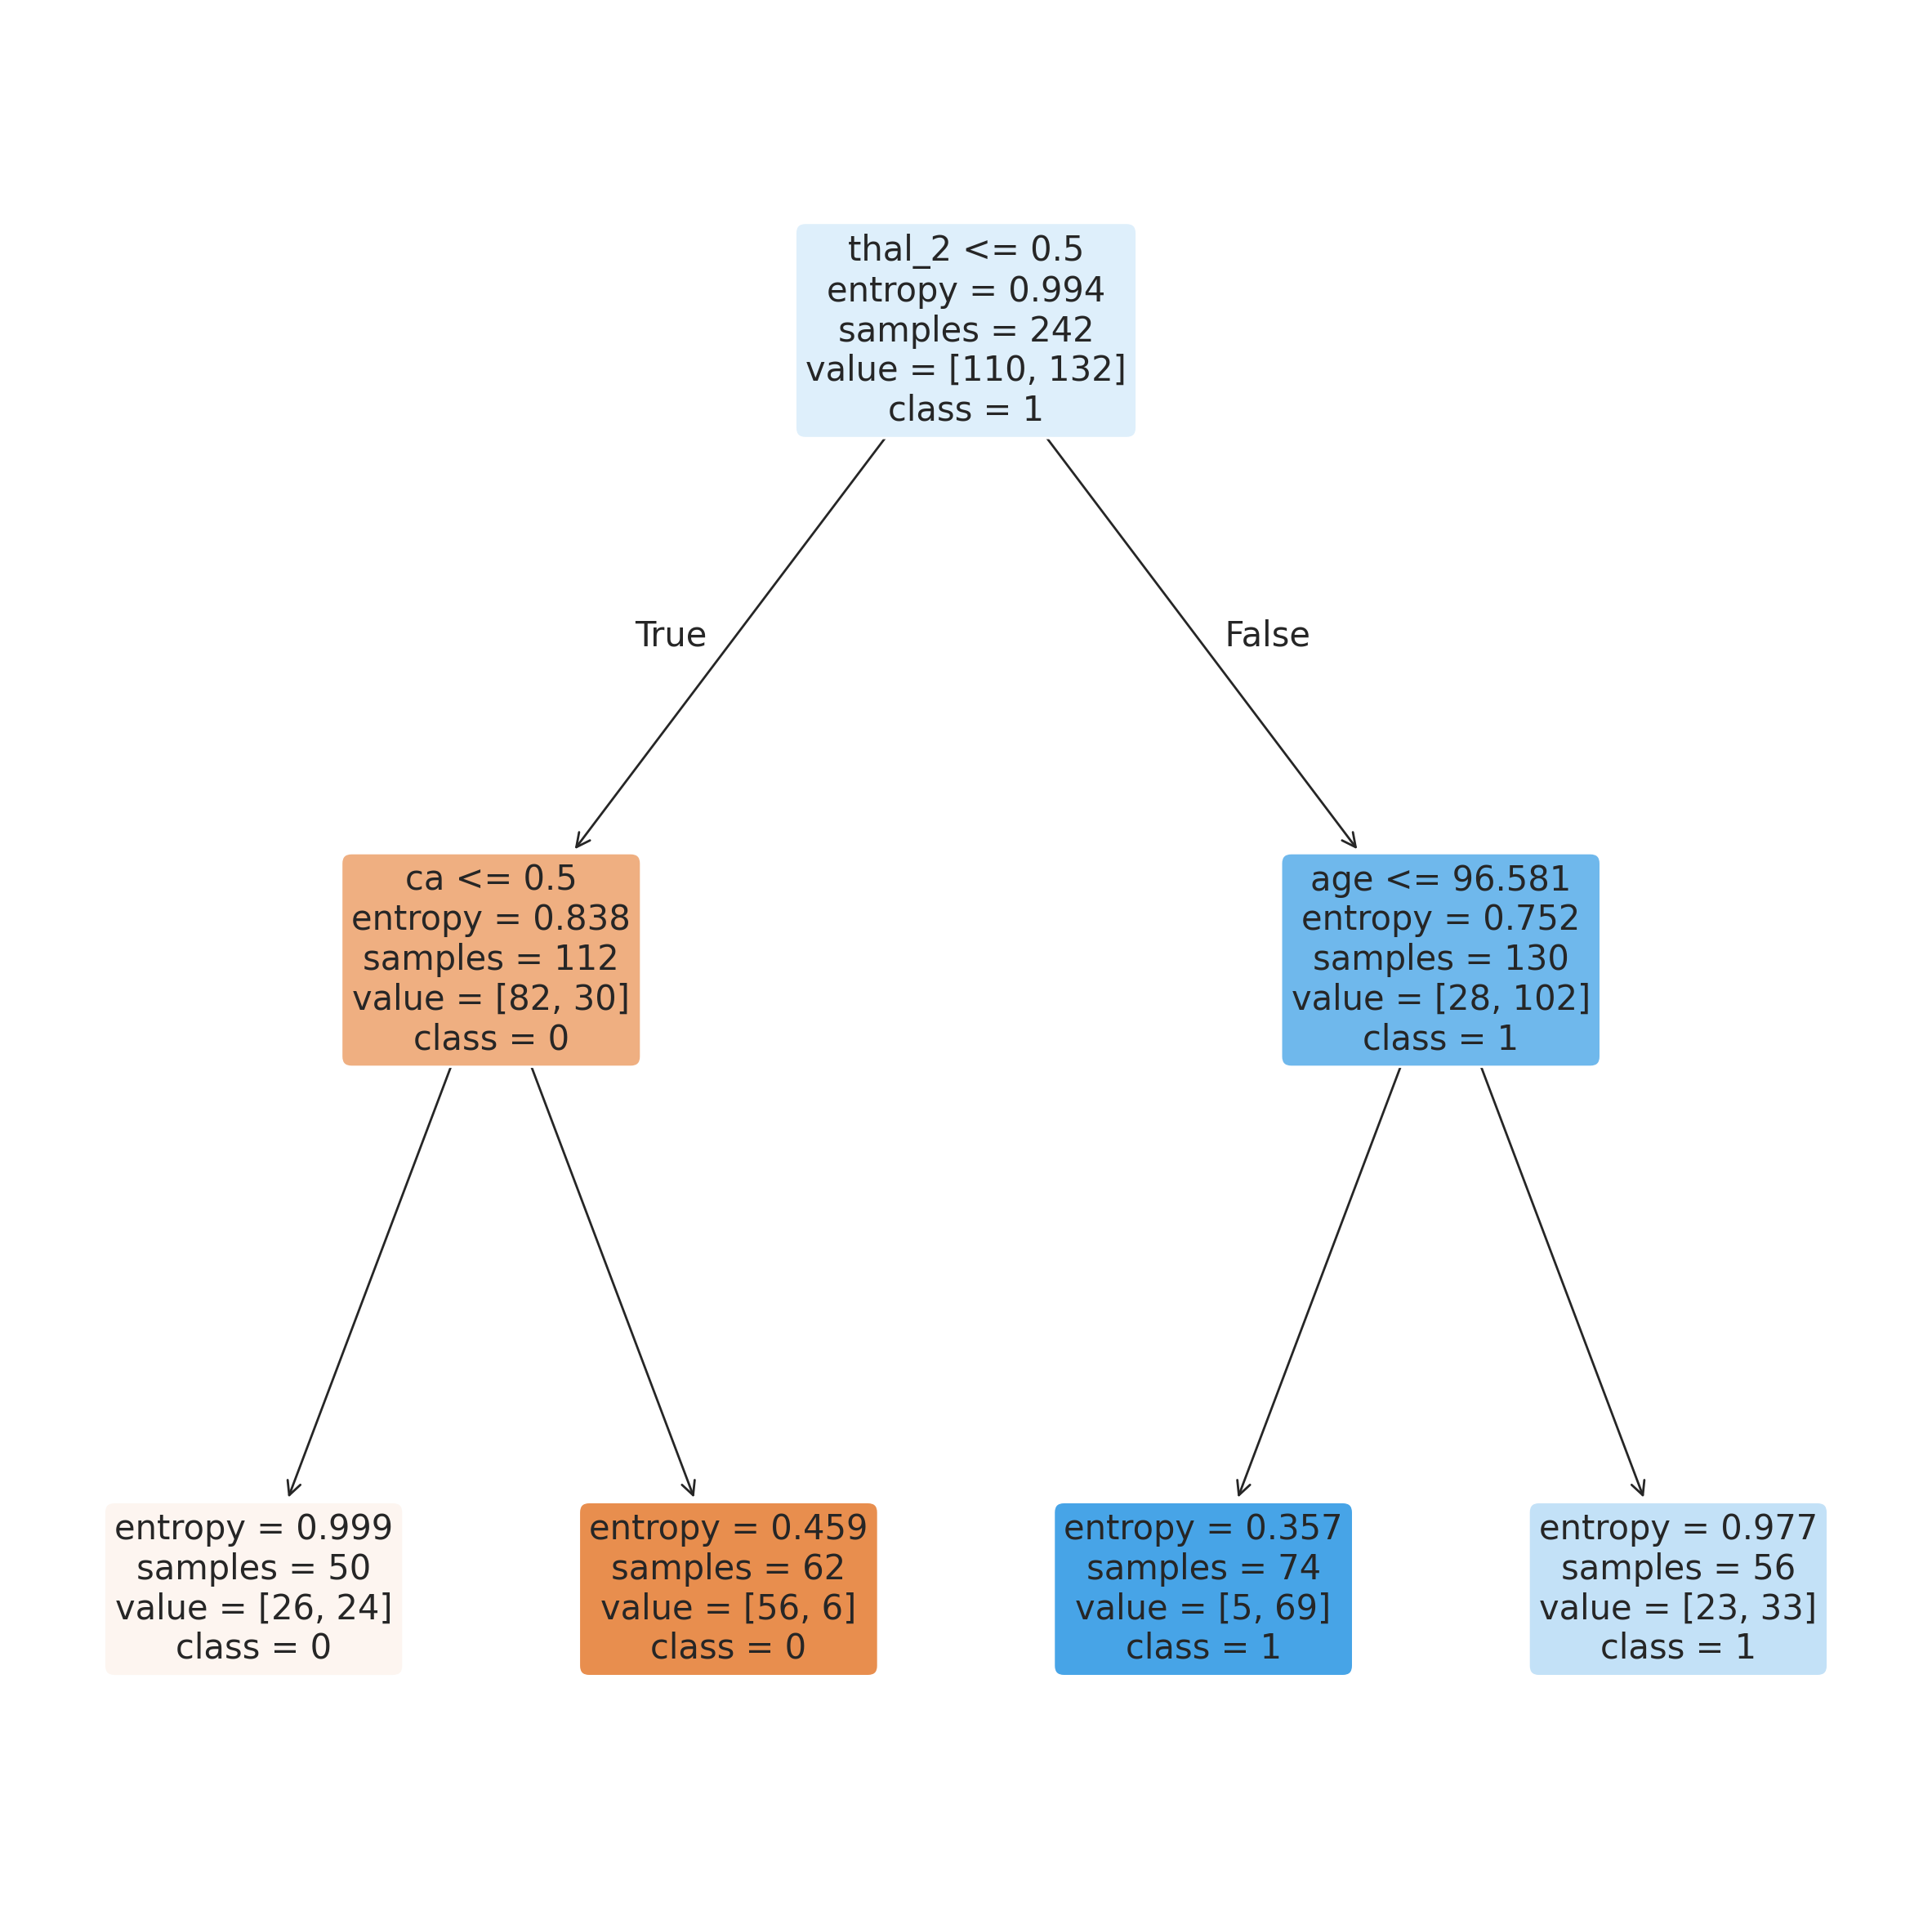

In [33]:
# Let us visualise the decision tree now
plt.figure(figsize=(15, 15))
from sklearn import tree
tree.plot_tree(dt_best, filled=True, feature_names=X_train.columns,
               class_names=[str(c) for c in dt_best.classes_], rounded=True, fontsize=15)
plt.show()

####Here at the end nodes minimum entropy is 0.357, so it does not distinguish the classes properly and distingusing on the basis of majority which is not a good sign.

##**Random Forest Model Building**

Now we shall implement the random forest to check we get better result or not.

In [34]:
# defining the base model
rf_base = RandomForestClassifier(random_state=0)

Again we shall use hypertuning for best result

In [35]:
# Providing choices
param_grid_rf = {
    'n_estimators': [10, 30, 70],
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 3, 4, 5, 6],
    'min_samples_leaf': [1, 2, 3],
    'criterion': ['gini', 'entropy'],
    'bootstrap': [True, False]
}

In [36]:
# Getting best estimator using tune_clf_hyperparameters
best_rf, best_rf_hparams = tune_clf_hyperparameters(rf_base, param_grid_rf, X_train, y_train)
print ('Random Forest Optimal Hyperparameters')
best_rf_hparams

Random Forest Optimal Hyperparameters


{'bootstrap': True,
 'criterion': 'gini',
 'max_depth': 2,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'n_estimators': 30}

This gives the optimum choices for which the recall value will be maximum

In [37]:
best_rf.fit(X_train, y_train)
best_rf.predict(X_test)

array([0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0])

This are the predictions for the testing data

In [38]:
# Evaluating the optimised model on training data
print(classification_report(y_train, best_rf.predict(X_train)))

              precision    recall  f1-score   support

           0       0.84      0.79      0.81       110
           1       0.83      0.87      0.85       132

    accuracy                           0.83       242
   macro avg       0.83      0.83      0.83       242
weighted avg       0.83      0.83      0.83       242



In [39]:
# Evaluating the optimised model on testing data
print(classification_report(y_test, best_rf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.85      0.79      0.81        28
           1       0.83      0.88      0.85        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



The recall score for both training and testing data has increased compared to the random forest. Beside recall, accuracy, precision score have also increased. This implies this moddel is performing better than Decision Tree model. There is no significant difference between the training scores and testing scores, so there is no sign of overfitting.

##**KNN Model Building**

In [40]:
# Define the base KNN model & set up pipeline with scaling
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

In [41]:
#Hyperparameter grid for KNN
knn_param_grid = {
    'knn__n_neighbors': list(range(1,12)),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

In [42]:
#Tuning
best_knn, best_knn_hparams = tune_clf_hyperparameters(knn_pipeline, knn_param_grid, X_train, y_train)
print ('KNN Optimal Hyperparameters:')
best_knn_hparams

KNN Optimal Hyperparameters:


{'knn__n_neighbors': 8, 'knn__p': 1, 'knn__weights': 'distance'}

In [43]:
# Evaluating the optimised model on the train data
print(classification_report(y_train, best_knn.predict(X_train)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       110
           1       1.00      1.00      1.00       132

    accuracy                           1.00       242
   macro avg       1.00      1.00      1.00       242
weighted avg       1.00      1.00      1.00       242



In [44]:
print(classification_report(y_test, best_knn.predict(X_test)))

              precision    recall  f1-score   support

           0       0.77      0.82      0.79        28
           1       0.84      0.79      0.81        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.81      0.80      0.80        61



The recall score along with precision and accuracy has fall. So, the Random Forest model still can be stated as the best model so far.

##**SVM Model Building**

In [45]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True))
])

In [46]:
# Hyperparameter grid for SVM
svm_param_grid = {
    'svm__C': [0.0011, 0.005, 0.01, 0.1, 1, 10, 20],
    'svm__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'svm__gamma': ['scale', 'auto', 0.1, 0.5, 1, 2, 3, 5],
    'svm__degree': [2, 3, 4, 5]
}

In [47]:
#Tuning
best_svm, best_svm_hparams = tune_clf_hyperparameters(svm_pipeline, svm_param_grid, X_train, y_train)
print ('SVM Optimal Hyperparameters:')
best_svm_hparams

SVM Optimal Hyperparameters:


{'svm__C': 0.0011,
 'svm__degree': 2,
 'svm__gamma': 'scale',
 'svm__kernel': 'linear'}

Now we get the optimal parameters for the best result

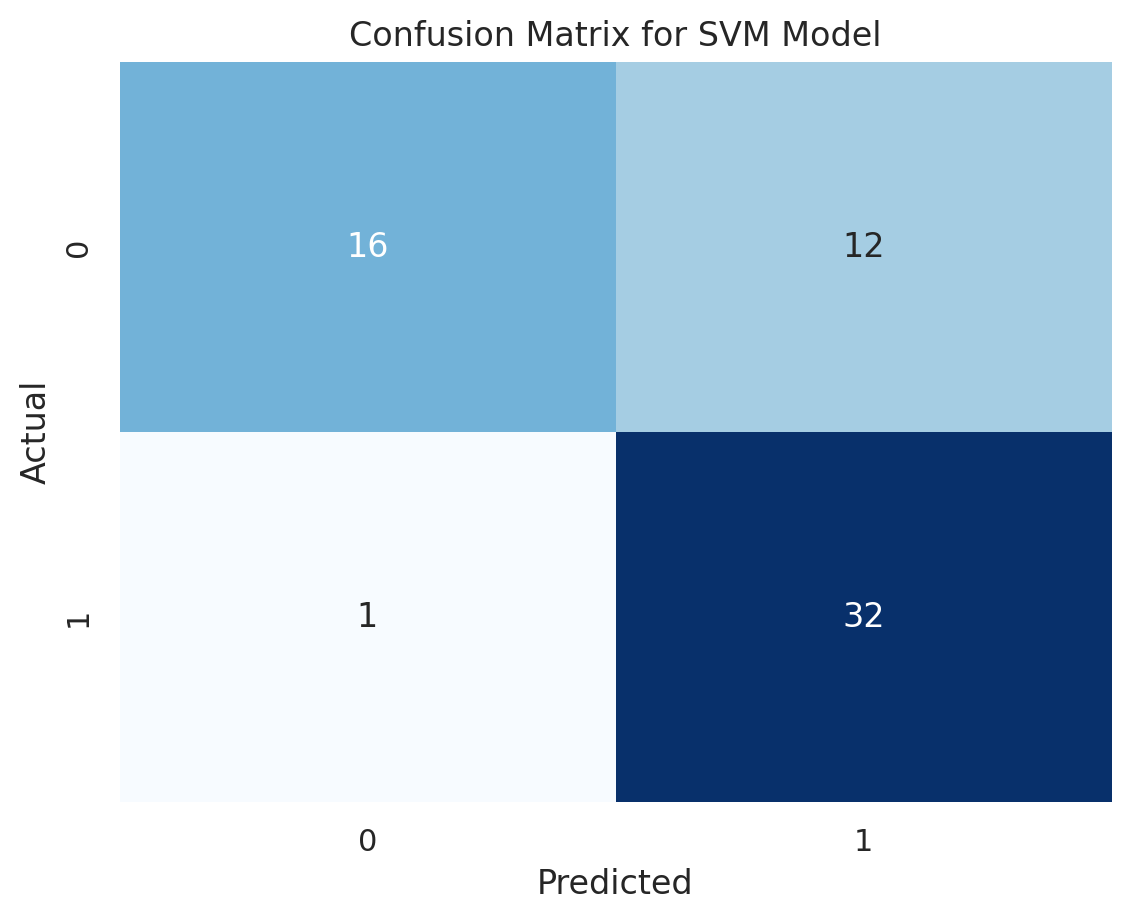

In [48]:
from sklearn.metrics import confusion_matrix
#Checking for the Confusion Matrix
y_pred_svm = best_svm.predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM Model')
plt.show()

In [49]:
# Evaluating the optimised model on the train data
print(classification_report(y_train, best_svm.predict(X_train)))

              precision    recall  f1-score   support

           0       0.92      0.54      0.68       110
           1       0.71      0.96      0.82       132

    accuracy                           0.77       242
   macro avg       0.82      0.75      0.75       242
weighted avg       0.81      0.77      0.76       242



In [50]:
# Evaluating the optimised model on the train data
print(classification_report(y_test, best_svm.predict(X_test)))

              precision    recall  f1-score   support

           0       0.94      0.57      0.71        28
           1       0.73      0.97      0.83        33

    accuracy                           0.79        61
   macro avg       0.83      0.77      0.77        61
weighted avg       0.83      0.79      0.78        61



####In this model the recall score for the positive class is considerabely high, 97%. Which means the model captures 97% of the patient with heart disease correctly. Moreover there is no significant difference between training and testing score. So, there is no sign of overfitting also.

####But the the recall for negative class is not good at all. It is only 57%. Which means the model predicts only 57% of normal patients correctly, other it states to be prone to disease. Though it will not result to a fatal effect but it may consern the goodwill of the hospital or organization.

####For now as it is important to have a high recall for the positive class, SVM model is the best after running so many models.

##**Conclusion**

In [51]:
from sklearn.metrics import classification_report
import pandas as pd

# predictions for all models
y_pred_dt = dt_best.predict(X_test)
y_pred_rf = best_rf.predict(X_test)
y_pred_knn = best_knn.predict(X_test)
y_pred_svm = best_svm.predict(X_test)

# classification reports
report_dt = classification_report(y_test, y_pred_dt, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
report_knn = classification_report(y_test, y_pred_knn, output_dict=True)
report_svm = classification_report(y_test, y_pred_svm, output_dict=True)


metrics = {
    'Decision Tree': {
        'Precision (Class 1)': report_dt['1']['precision'],
        'Recall (Class 1)': report_dt['1']['recall'],
        'F1-Score (Class 1)': report_dt['1']['f1-score'],
        'Accuracy': report_dt['accuracy']
    },
    'Random Forest': {
        'Precision (Class 1)': report_rf['1']['precision'],
        'Recall (Class 1)': report_rf['1']['recall'],
        'F1-Score (Class 1)': report_rf['1']['f1-score'],
        'Accuracy': report_rf['accuracy']
    },
    'KNN': {
        'Precision (Class 1)': report_knn['1']['precision'],
        'Recall (Class 1)': report_knn['1']['recall'],
        'F1-Score (Class 1)': report_knn['1']['f1-score'],
        'Accuracy': report_knn['accuracy']
    },
    'SVM': {
        'Precision (Class 1)': report_svm['1']['precision'],
        'Recall (Class 1)': report_svm['1']['recall'],
        'F1-Score (Class 1)': report_svm['1']['f1-score'],
        'Accuracy': report_svm['accuracy']
    }
}

# Creating a DataFrame for comparison
metrics_df = pd.DataFrame(metrics).T
display(metrics_df.round(3))

,Precision (Class 1),Recall (Class 1),F1-Score (Class 1),Accuracy
Decision Tree,0.778,0.848,0.812,0.787
Random Forest,0.829,0.879,0.853,0.836
KNN,0.839,0.788,0.812,0.803
SVM,0.727,0.970,0.831,0.787


Comparing the above table in this case of medical treatment, recall for the positive class is most necessary. So it will be reasonable to choose SVM model for prediction purpose as all the patients with heart disease will be correctly identified.

In [52]:

def preprocess_new_data(new_data_dict):

    # Create a DataFrame with all expected columns from training data, initialized to 0
    # This ensures that all features the model expects are present and in correct order.
    processed_df = pd.DataFrame(0, index=[0], columns=original_feature_order)

    # Fill the template with the values from the new_data_dict
    for col, value in new_data_dict.items():
        if col in processed_df.columns:
            processed_df[col] = value

    # Ensure 'oldpeak' is positive before Box-Cox transformation
    # This step was done during training, so it must be replicated here.
    if 'oldpeak' in processed_df.columns:
        processed_df['oldpeak'] = processed_df['oldpeak'] + 0.0001

    # Apply Box-Cox transformation using stored lambdas to continuous features
    for col in continuous_features:
        if col in processed_df.columns and col in lambdas:
            # Box-Cox expects a scalar value for transformation of a single input.
            current_value = processed_df[col].iloc[0]
            if current_value <= 0:
                pass
            processed_df[col] = boxcox(current_value, lmbda=lambdas[col])


    return processed_df

def predict_heart_disease(model, preprocessed_data_df):

    # The 'model' here is 'best_svm', which is a scikit-learn Pipeline.
    # It will internally apply StandardScaler (its first step) then SVC.
    prediction = model.predict(preprocessed_data_df)[0]
    probability = model.predict_proba(preprocessed_data_df)[0]
    return prediction, probability


## **Heart Disease Prediction System**

This section allows you to input new patient data and get a prediction from the trained SVM model regarding the likelihood of heart disease.

### **Manual Heart Disease Prediction System**

Please provide the following patient details when prompted. The system will use these values to predict the likelihood of heart disease.

In [55]:

print("Please enter the following patient features:")

input_data = {}

# Get numerical inputs
input_data['age'] = float(input("Enter Age (e.g., 50): "))
input_data['trestbps'] = float(input("Enter Resting Blood Pressure in mm/Hg (trestbps, e.g., 120): "))
input_data['chol'] = float(input("Enter Serum Cholesterol in mg/dl (chol, e.g., 240): "))
input_data['thalach'] = float(input("Enter Maximum Heart Rate achieved during a stress test (thalach, e.g., 150): "))
input_data['oldpeak'] = float(input("Enter ST depression induced by exercise relative to rest (oldpeak, e.g., 1.0): "))

# Get integer-encoded categorical inputs
input_data['sex'] = int(input("Enter Sex (0 for Male, 1 for Female): "))
input_data['fbs'] = int(input("Enter Fasting Blood Sugar > 120 mg/dl (fbs:- 0 for False, 1 for True): "))
input_data['exang'] = int(input("Enter Exercise Induced Angina (exang:- 0 for No, 1 for Yes): "))
input_data['slope'] = int(input("Enter the slope of the peak exercise ST segment (slope:- 0: upsloping, 1: flat, 2: downsloping): "))
input_data['ca'] = int(input("Enter Number of major vessels (0-4) colored by fluoroscopy (ca, e.g., 0): "))

# Get one-hot encoded categorical inputs
cp_val = int(input("Enter Chest Pain Type (cp:- 0: Typical Angina, 1: Atypical Angina, 2: Non-anginal Pain, 3: Asymptomatic): "))
restecg_val = int(input("Enter Resting ECG Results (restecg:- 0: Normal, 1: ST-T wave abnormality, 2: Left ventricular hypertrophy): "))
thal_val = int(input("Enter Thalassemia (thal:- 0: Normal, 1: Fixed Defect, 2: Reversible Defect, 3: Unknown): "))

# Define original_feature_order for correct one-hot encoding handling
original_feature_order = X.columns.tolist()

# Initialize all one-hot encoded columns to 0
for prefix in ['cp', 'restecg', 'thal']:
    for col in original_feature_order:
        if col.startswith(prefix + '_') and col[len(prefix) + 1:].isdigit():
            input_data[col] = 0

# Set the corresponding one-hot encoded column to 1 based on user input
if cp_val > 0: input_data[f'cp_{cp_val}'] = 1
if restecg_val > 0: input_data[f'restecg_{restecg_val}'] = 1
if thal_val > 0: input_data[f'thal_{thal_val}'] = 1

# Preprocess the new input data
processed_input = preprocess_new_data(input_data)

# Make prediction
prediction, probability = predict_heart_disease(best_svm, processed_input)

print("\n--- Prediction Results ---")
if prediction == 1:
    print(f"The patient is likely to have heart disease with a probability of {probability[1]:.2f}")
else:
    print(f"The patient is unlikely to have heart disease with a probability of {probability[0]:.2f}")

Please enter the following patient features:
Enter Age (e.g., 50): 65
Enter Resting Blood Pressure in mm/Hg (trestbps, e.g., 120): 140
Enter Serum Cholesterol in mg/dl (chol, e.g., 240): 417
Enter Maximum Heart Rate achieved during a stress test (thalach, e.g., 150): 157
Enter ST depression induced by exercise relative to rest (oldpeak, e.g., 1.0): 0.8
Enter Sex (0 for Male, 1 for Female): 0
Enter Fasting Blood Sugar > 120 mg/dl (fbs:- 0 for False, 1 for True): 1
Enter Exercise Induced Angina (exang:- 0 for No, 1 for Yes): 0
Enter the slope of the peak exercise ST segment (slope:- 0: upsloping, 1: flat, 2: downsloping): 2
Enter Number of major vessels (0-4) colored by fluoroscopy (ca, e.g., 0): 1
Enter Chest Pain Type (cp:- 0: Typical Angina, 1: Atypical Angina, 2: Non-anginal Pain, 3: Asymptomatic): 2
Enter Resting ECG Results (restecg:- 0: Normal, 1: ST-T wave abnormality, 2: Left ventricular hypertrophy): 0
Enter Thalassemia (thal:- 0: Normal, 1: Fixed Defect, 2: Reversible Defect, 

As we observed earlier, the recall score for the negative category (``target``= 0) is quite low. This implies that most of the time the model predicts a healthy patients to be cardiac disease prone. So, to resolve this problem the probability score is also being included. In simple terms the model states how much it is confident about the result.

###**NOTE**: Any Machine Learning model must be used in order to assist the professionals, not to replace them. The final judgement must be made by the user not the machine all alone. Medical feald is a very sensetive domain to work on. A simple mistake can be turned into a fatal one. No matter how much well trained model it is, how much it correctly predicts, The final decission must be taken a professional doctor only.
---

